**Current Progress:** I have converted my code to python. I applied a log transformation to the skewed price data, creating a new price_log feature. Numeric columns were scaled using StandardScaler and categorical columns were one-hot encoded using OneHotEncoder in the pipeline. I also removed the 'zestimate' feature. This combined greatly improved my models' performance. I also adjusted my XGBoosting model by adding hyperparameters and retrieving the best-performing model.

**What I am working on:** I am working on creating more features and implementing both sentiment analysis and keyword extraction. I am also continuing to find ways to improve both my models. I am making graphs that will better present my data and recommendations.

**Challenges I am Facing:** I am wondering if I should remove outliers from other variables than price, or not at all. I am unsure if I performed sentiment analysis properly. I am  unsure if you wanted me to add another or a different model. I am also unsure if my extra XGBoosting Model is better than the original one. I would also like any advice on creating new features or how to better clean my data.

**Short-Term Goals:** I plan to implement keyword extraction and improve my XGboosting model. I would also like to improve my preprocessing if you have any recommendations. I also would like to implement keyword extraction and find more features in my dataset. I would also like to add more graphs to represent my data.

**Contingency Plan:** If I can't figure out how to achieve my goals I would like to find out ways to correlate the data I have towards my recommendations towards LotwiZe. If I can't adjust my XGBoosting model I could switch to a different model to represent my data instead.

In [1]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import spacy
import transformers
from textblob import TextBlob

from sklearn.pipeline import Pipeline # Import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


In [ ]:
# Load the CSV into a DataFrame
lotwize = pd.read_csv('lotwize_case.csv', encoding='ISO-8859-1')

**Data Preprocessing**

In [ ]:
# 2. Preprocess Text Data: (You might need to add more preprocessing steps)
lotwize['description'] = lotwize['description'].astype(str).str.lower() # Convert to string and lowercase

# 3. Perform Sentiment Analysis with TextBlob
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

lotwize['sentiment'] = lotwize['description'].apply(get_sentiment)


In [ ]:
# Step 1: Impute missing values for numeric columns like 'price' and 'adTargets/sqft'
lotwize['price'].fillna(lotwize['price'].median(), inplace=True)
lotwize['adTargets/sqft'].fillna(lotwize['adTargets/sqft'].median(), inplace=True)

# Step 2: Recreate the 'price_per_sqft' feature after imputing values
lotwize['price_per_sqft'] = lotwize['price'] / lotwize['adTargets/sqft']

# Step 3: Impute missing values in 'yearBuilt' and create 'age' column
lotwize['yearBuilt'] = pd.to_numeric(lotwize['yearBuilt'], errors='coerce')
lotwize['yearBuilt'].fillna(lotwize['yearBuilt'].median(), inplace=True)
lotwize['age'] = 2024 - lotwize['yearBuilt']

# Handle numeric columns: Impute missing values with median
numeric_cols = lotwize.select_dtypes(include='number').columns
lotwize[numeric_cols] = lotwize[numeric_cols].fillna(lotwize[numeric_cols].median())

# Handle missing values for categorical columns by filling with the mode (most frequent value)
categorical_cols = lotwize.select_dtypes(include='object').columns
for col in categorical_cols:
    lotwize[col].fillna(lotwize[col].mode()[0], inplace=True)

# Step 4: Calculate 'rooms_per_bathroom'
# Check if 'bathrooms' is 0 before division to avoid inf
lotwize['rooms_per_bathroom'] = np.where(lotwize['bathrooms'] != 0,
                                        (lotwize['bedrooms'] + lotwize['bathrooms']) / lotwize['bathrooms'],
                                        0)  # Replace inf with 0, you can choose another value

# Step 5: Log transformation for skewed 'price'
lotwize['price_log'] = np.log1p(lotwize['price'])

# Step 8: Ensure that all infinite values are handled and numeric columns are scaled
scaler = StandardScaler()

# Replace infinite values with NaN
lotwize[numeric_cols] = lotwize[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Impute NaN values with the median (or another strategy)
lotwize[numeric_cols] = lotwize[numeric_cols].fillna(lotwize[numeric_cols].median())

# Apply StandardScaler to the numeric columns
lotwize[numeric_cols] = scaler.fit_transform(lotwize[numeric_cols])

# Step 9: Create the column transformer for preprocessing
contin = ['age', 'price_per_sqft', 'rooms_per_bathroom', 'sentiment']  # Replace with actual continuous columns
categorical = ['county', 'nearbyHomes/1/propertyTypeDimension', 'nearbyHomes/1/state']  # Replace with actual categorical columns

<ipython-input-4-67f6be879c46>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lotwize['price'].fillna(lotwize['price'].median(), inplace=True)
<ipython-input-4-67f6be879c46>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

Gradient Boosting Model

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer

# Create a ColumnTransformer to apply StandardScaler only to 'contin' columns
pre = make_column_transformer(
    (StandardScaler(), contin),  # Apply StandardScaler to continuous columns
    (OneHotEncoder(handle_unknown='ignore'), categorical),  # Apply OneHotEncoder to categorical columns and ignore unknown categories
    remainder='passthrough'  # Keep other columns as they are
)

# Step 1: Define the model (Gradient Boosting Regressor)
gb_model = GradientBoostingRegressor()

# Step 2: Create a Full Pipeline (reusing your preprocessing steps)
pipe = Pipeline([
    ("pre", pre),  # Reusing the preprocessing transformer
    ("model", gb_model)
])

# Step 3: Define the target variable and split the data
X = lotwize[contin + categorical]  # Subset to columns to be transformed
y = lotwize['price_log']  # Target variable

# Split the data into training and test sets (20% train, 80% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

# Step 4: Fit the Gradient Boosting model on the training data
pipe.fit(X_train, y_train)

# Step 5: Make predictions on the test data
predictions_test = pipe.predict(X_test)

# Step 6: Make predictions on the train data
predictions_train = pipe.predict(X_train)

# Step 7: Evaluate the model's performance on Test set
mse_test = mean_squared_error(y_test, predictions_test)
r2_test = r2_score(y_test, predictions_test)
rmse_test = mean_squared_error(y_test, predictions_test, squared=False)
mae_test = mean_absolute_error(y_test, predictions_test)

print("Test Set Metrics:")
print(f"Mean Squared Error: {mse_test}")
print(f"R^2 Score: {r2_test}")
print(f"RMSE: {rmse_test}")
print(f"MAE: {mae_test}")

# Step 8: Evaluate the model's performance on Train set
mse_train = mean_squared_error(y_train, predictions_train)
r2_train = r2_score(y_train, predictions_train)
rmse_train = mean_squared_error(y_train, predictions_train, squared=False)
mae_train = mean_absolute_error(y_train, predictions_train)

print("\nTrain Set Metrics:")
print(f"Mean Squared Error: {mse_train}")
print(f"R^2 Score: {r2_train}")
print(f"RMSE: {rmse_train}")
print(f"MAE: {mae_train}")

Test Set Metrics:
Mean Squared Error: 0.07401174520201555
R^2 Score: 0.8180072949538699
RMSE: 0.2720509974288195
MAE: 0.18108142470779973

Train Set Metrics:
Mean Squared Error: 0.054394994547564114
R^2 Score: 0.8685429913230027
RMSE: 0.23322734519683602
MAE: 0.15633884634418443


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


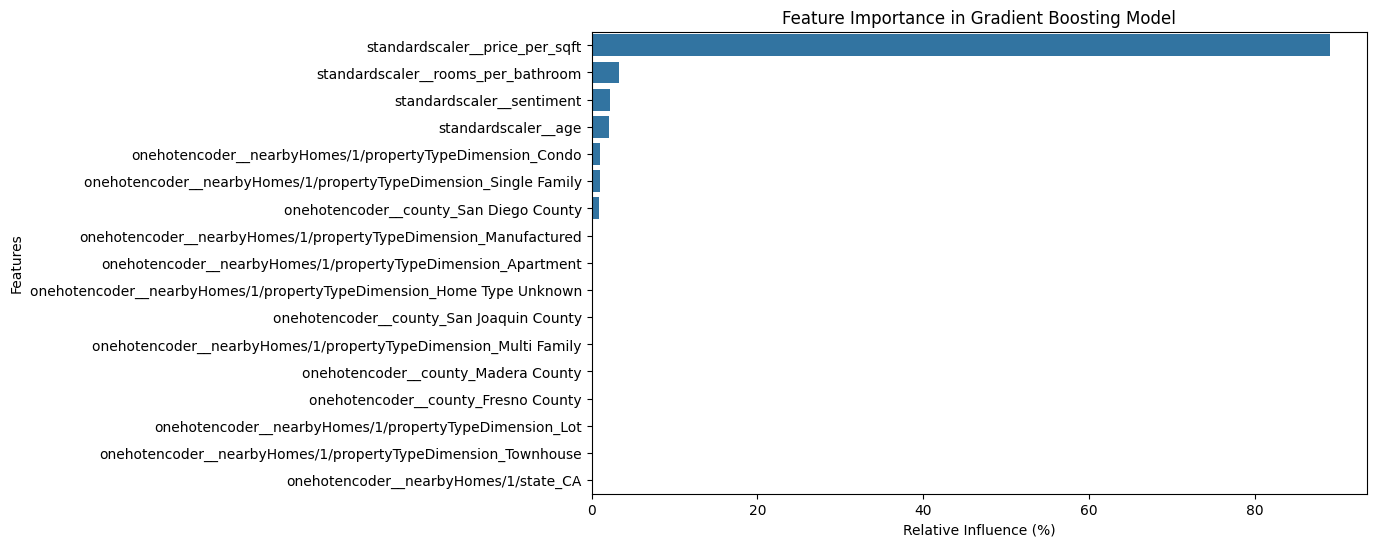

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names after transformation
feature_names = pipe.named_steps['pre'].get_feature_names_out(input_features=X_train.columns)

# Extract feature importances from the Gradient Boosting model
importance = pipe.named_steps['model'].feature_importances_

# Combine the feature names with their importance scores into a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,  # Use transformed feature names
    'Relative Influence (%)': importance * 100  # Convert to percentage
})

# Sort the features by their relative importance
feature_importance = feature_importance.sort_values(by='Relative Influence (%)', ascending=False)

# Plot the feature importance using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Relative Influence (%)', y='Feature', data=feature_importance)

# Add labels and title
plt.xlabel('Relative Influence (%)')
plt.ylabel('Features')
plt.title('Feature Importance in Gradient Boosting Model')

# Show the plot
plt.show()


XGBoosting Model

In [ ]:
from xgboost import DMatrix

# Step 5: Convert non-numeric columns to numeric codes
non_numeric_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("Non-numeric columns:", non_numeric_columns)

# Convert all non-numeric columns in both training and testing sets
for col in non_numeric_columns:
    X_train[col] = X_train[col].astype('category').cat.codes
    X_test[col] = X_test[col].astype('category').cat.codes

# Step 6: Ensure all columns are numeric
all_numeric = X_train.apply(lambda x: np.issubdtype(x.dtype, np.number)).all()
if not all_numeric:
    raise ValueError("Some columns are still not numeric!")

# Step 7: Convert the data into matrix format for XGBoost
dtrain = DMatrix(data=X_train, label=y_train)
dtest = DMatrix(data=X_test, label=y_test)

# Check final data format
X_train.head(), y_train.head()

Non-numeric columns: ['county', 'nearbyHomes/1/propertyTypeDimension', 'nearbyHomes/1/state']


(           age  price_per_sqft  rooms_per_bathroom  sentiment  county  \
 4109 -0.153519       -0.048047            2.333333  -1.001844       0   
 4969 -0.146694       -0.049015            4.000000   1.250810       0   
 4904  0.030772       -0.049877            2.500000   1.053707       0   
 7294  0.017121       -0.019114            2.500000  -1.001844       0   
 514   0.133156        0.003257            4.000000  -1.001844       0   
 
       nearbyHomes/1/propertyTypeDimension  nearbyHomes/1/state  
 4109                                    6                    0  
 4969                                    6                    0  
 4904                                    6                    0  
 7294                                    6                    0  
 514                                     6                    0  ,
 4109    13.017005
 4969    12.531776
 4904    12.733758
 7294    13.748303
 514     14.085538
 Name: price_log, dtype: float64)

In [ ]:
from xgboost import XGBRegressor

# 1. Define and Train the XGBoost Model:
model = XGBRegressor()  # Create an XGBoost regressor object
model.fit(X_train, y_train)  # Train the model

# 2. Make Predictions:
predictions_test = model.predict(X_test)  # Predict using the test DMatrix
predictions_train = model.predict(X_train)  # Predict using the train DMatrix


# 3. Calculate Metrics for Test Set:
rmse_test = mean_squared_error(y_test, predictions_test, squared=False)
mae_test = mean_absolute_error(y_test, predictions_test)
mse_test = mean_squared_error(y_test, predictions_test)
r2_test = r2_score(y_test, predictions_test)

# 4. Calculate Metrics for Train Set:
rmse_train = mean_squared_error(y_train, predictions_train, squared=False)
mae_train = mean_absolute_error(y_train, predictions_train)
mse_train = mean_squared_error(y_train, predictions_train)
r2_train = r2_score(y_train, predictions_train)

# 5. Print the Metrics:
print("Test Set Metrics:")
print(f"RMSE: {rmse_test}")
print(f"MAE: {mae_test}")
print(f"MSE: {mse_test}")
print(f"R^2: {r2_test}")

print("\nTrain Set Metrics:")
print(f"RMSE: {rmse_train}")
print(f"MAE: {mae_train}")
print(f"MSE: {mse_train}")
print(f"R^2: {r2_train}")

Test Set Metrics:
RMSE: 0.29274974524070424
MAE: 0.20506304675933995
MSE: 0.08570241333849724
R^2: 0.789260285784615

Train Set Metrics:
RMSE: 0.08007004094209974
MAE: 0.04595694979262266
MSE: 0.006411211456469528
R^2: 0.9845059515664402


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


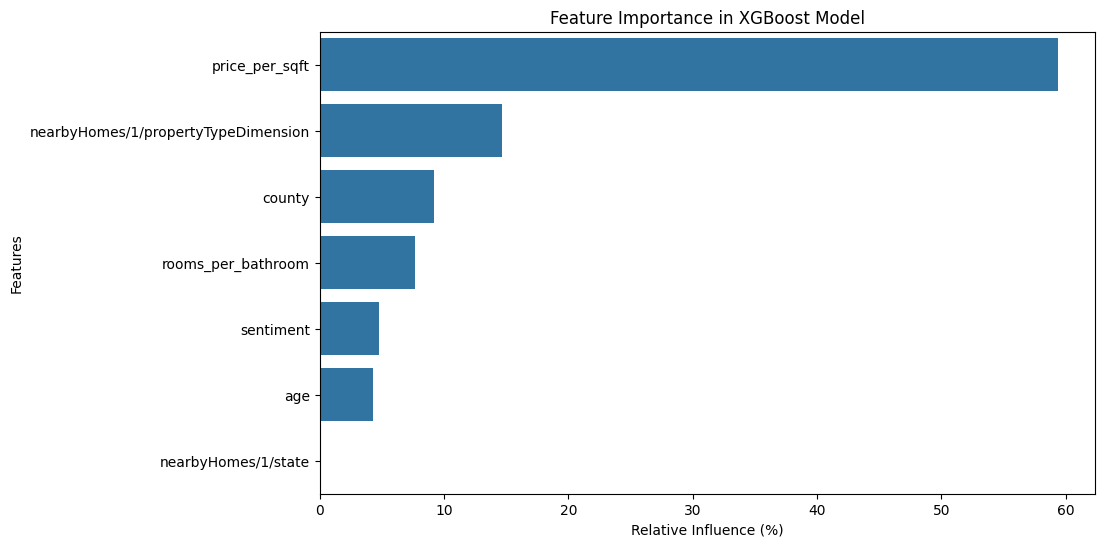

In [ ]:
# Get feature names (assuming X_train has original feature names)
feature_names = X_train.columns

# Extract feature importances from the XGBoost model
importance = model.feature_importances_

# Combine feature names and importances into a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Relative Influence (%)': importance * 100  # Convert to percentage
})

# Sort features by importance
feature_importance = feature_importance.sort_values(by='Relative Influence (%)', ascending=False)

# Plot the feature importance using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Relative Influence (%)', y='Feature', data=feature_importance)

# Add labels and title
plt.xlabel('Relative Influence (%)')
plt.ylabel('Features')
plt.title('Feature Importance in XGBoost Model')

# Show the plot
plt.show()

Extra XGBoosting Model

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# Define the XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse')

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=10
)

# Fit the GridSearchCV object to the data
grid_search.fit(X_train, y_train)

# Get the best model and its parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

#print("Best Hyperparameters:", best_params)

# Make predictions on the test and train sets
predictions_test = best_model.predict(X_test)
predictions_train = best_model.predict(X_train)

# Calculate metrics for test set
rmse_test = mean_squared_error(y_test, predictions_test, squared=False)
mae_test = mean_absolute_error(y_test, predictions_test)
mse_test = mean_squared_error(y_test, predictions_test)
r2_test = r2_score(y_test, predictions_test)

# Calculate metrics for train set
rmse_train = mean_squared_error(y_train, predictions_train, squared=False)
mae_train = mean_absolute_error(y_train, predictions_train)
mse_train = mean_squared_error(y_train, predictions_train)
r2_train = r2_score(y_train, predictions_train)

# Print the metrics
print("\nTest Set Metrics:")
print(f"RMSE: {rmse_test}")
print(f"MAE: {mae_test}")
print(f"MSE: {mse_test}")
print(f"R^2: {r2_test}")

print("\nTrain Set Metrics:")
print(f"RMSE: {rmse_train}")
print(f"MAE: {mae_train}")
print(f"MSE: {mse_train}")
print(f"R^2: {r2_train}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV 1/5; 1/27] START learning_rate=0.01, max_depth=3, n_estimators=100..........
[CV 1/5; 1/27] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=-0.371 total time=   0.0s
[CV 2/5; 1/27] START learning_rate=0.01, max_depth=3, n_estimators=100..........
[CV 2/5; 1/27] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=-0.378 total time=   0.1s
[CV 3/5; 1/27] START learning_rate=0.01, max_depth=3, n_estimators=100..........
[CV 3/5; 1/27] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=-0.401 total time=   0.0s
[CV 4/5; 1/27] START learning_rate=0.01, max_depth=3, n_estimators=100..........
[CV 4/5; 1/27] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=-0.382 total time=   0.0s
[CV 5/5; 1/27] START learning_rate=0.01, max_depth=3, n_estimators=100..........
[CV 5/5; 1/27] END learning_rate=0.01, max_depth=3, n_estimators=100;, score=-0.376 total time=   0.1s
[CV 1/5; 2/27] STA

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


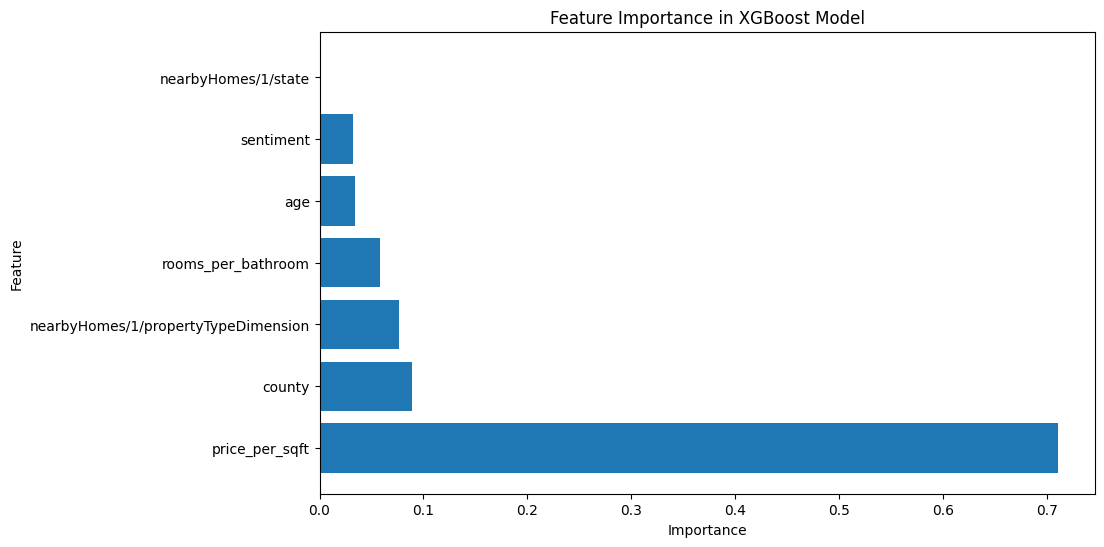

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances
importance = best_model.feature_importances_

# Create a DataFrame for feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,  # Use original feature names from X_train
    'Importance': importance
})

# Sort features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Create bar plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in XGBoost Model')
plt.show()

In [ ]:
print(lotwize.dtypes)

schools/0/distance      float64
schools/1/grades         object
schools/2/level          object
schools/0/name           object
schools/1/rating        float64
                         ...   
resoFacts/flooring/0     object
price_per_sqft          float64
age                     float64
rooms_per_bathroom      float64
price_log               float64
Length: 360, dtype: object


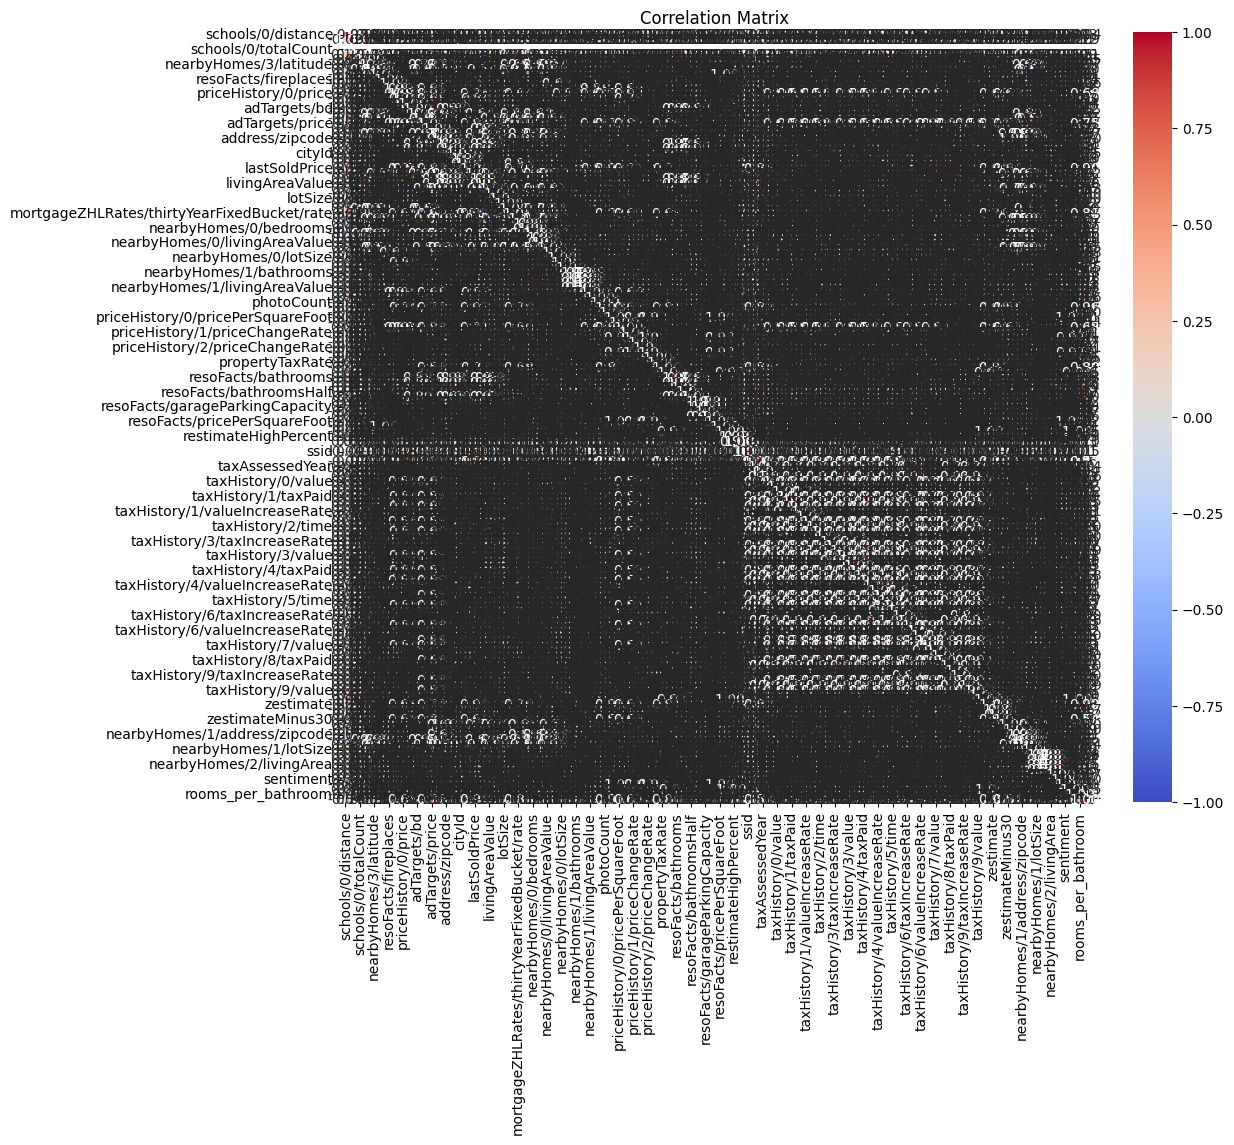

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'lotwize' is your DataFrame
# Select only numeric columns for correlation calculation
numeric_lotwize = lotwize.select_dtypes(include=['number']) # This line is added

correlation_matrix = numeric_lotwize.corr() # Changed 'lotwize' to 'numeric_lotwize'
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

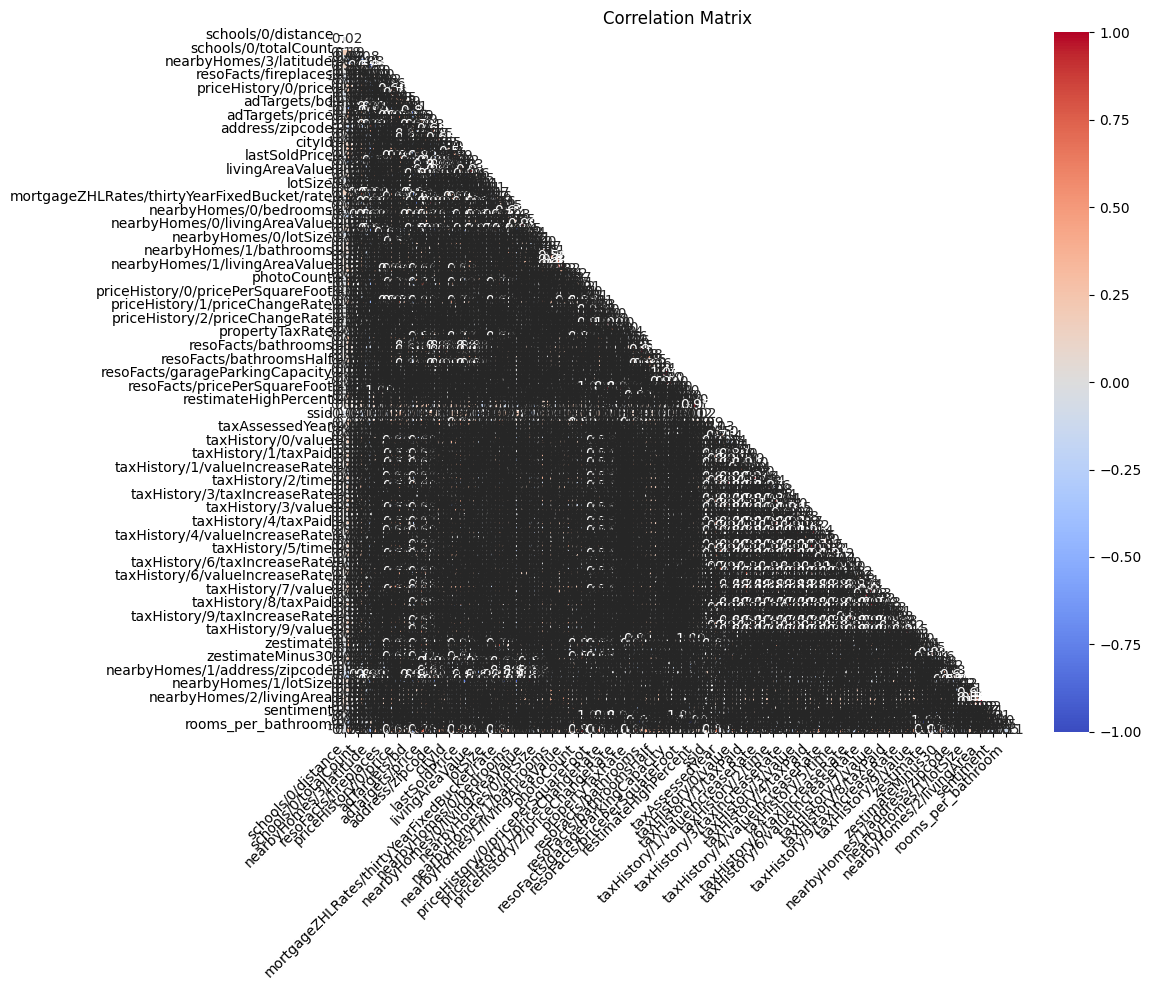

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Assuming 'lotwize' is your DataFrame
# Select only numeric columns for correlation calculation
numeric_lotwize = lotwize.select_dtypes(include=['number'])

correlation_matrix = numeric_lotwize.corr()

# Enhancements:
# 1. Mask upper triangle for cleaner look
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 2. Customize colormap and color range
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=mask, vmin=-1, vmax=1)

# 3. Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# 4. Add title and adjust layout
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()